In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred, verbose=True):
    cm = confusion_matrix(y_true, y_pred)

    # Extract values
    TN, FP, FN, TP = cm.ravel()

    # Core metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Derived metrics
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
    fpr = FP / (FP + TN) if (FP + TN) != 0 else 0
    fnr = FN / (FN + TP) if (FN + TP) != 0 else 0

    if verbose:
        print("Confusion Matrix:")
        print(cm)
        print("\nMetrics:")
        print(f"Accuracy     : {accuracy:.4f}")
        print(f"Precision    : {precision:.4f}")
        print(f"Recall       : {recall:.4f}")
        print(f"F1 Score     : {f1:.4f}")
        print(f"Specificity  : {specificity:.4f}")
        print(f"FPR          : {fpr:.4f}")
        print(f"FNR          : {fnr:.4f}")

    return {
        "cm": cm,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "specificity": specificity,
        "fpr": fpr,
        "fnr": fnr
    }

In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, precision_score


# ===== LOAD DATA =====
X_old = np.load("X_old.npy")
y_old = np.load("y_old.npy")

X_new = np.load("X_new.npy")
y_new = np.load("y_new.npy")


# ===== SPLIT NEW DATA =====
X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(
    X_new,
    y_new,
    test_size=0.2,
    stratify=y_new,
    random_state=42
)


# ===== COMBINE TRAINING =====
X_train = np.concatenate([X_old, X_new_train])
y_train = np.concatenate([y_old, y_new_train])

X_test = X_new_test
y_test = y_new_test

# ===== MODEL =====
model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=2.0,
    eval_metric="logloss"
)


# ===== TRAIN =====
model.fit(X_train, y_train)


# ===== EVALUATE =====
y_prob = model.predict_proba(X_test)[:, 1]
for t in [0.5, 0.6, 0.65, 0.7, 0.75]:
    y_pred = (y_prob >= t).astype(int)
    print(f"\nThreshold: {t}")
    evaluate_model(y_test, y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("Recall (occupied):", recall_score(y_test, y_pred))


Threshold: 0.5
Confusion Matrix:
[[254  42]
 [ 24 238]]

Metrics:
Accuracy     : 0.8817
Precision    : 0.8500
Recall       : 0.9084
F1 Score     : 0.8782
Specificity  : 0.8581
FPR          : 0.1419
FNR          : 0.0916

Threshold: 0.6
Confusion Matrix:
[[266  30]
 [ 33 229]]

Metrics:
Accuracy     : 0.8871
Precision    : 0.8842
Recall       : 0.8740
F1 Score     : 0.8791
Specificity  : 0.8986
FPR          : 0.1014
FNR          : 0.1260

Threshold: 0.65
Confusion Matrix:
[[273  23]
 [ 39 223]]

Metrics:
Accuracy     : 0.8889
Precision    : 0.9065
Recall       : 0.8511
F1 Score     : 0.8780
Specificity  : 0.9223
FPR          : 0.0777
FNR          : 0.1489

Threshold: 0.7
Confusion Matrix:
[[277  19]
 [ 45 217]]

Metrics:
Accuracy     : 0.8853
Precision    : 0.9195
Recall       : 0.8282
F1 Score     : 0.8715
Specificity  : 0.9358
FPR          : 0.0642
FNR          : 0.1718

Threshold: 0.75
Confusion Matrix:
[[284  12]
 [ 56 206]]

Metrics:
Accuracy     : 0.8781
Precision    : 0.9450
Rec

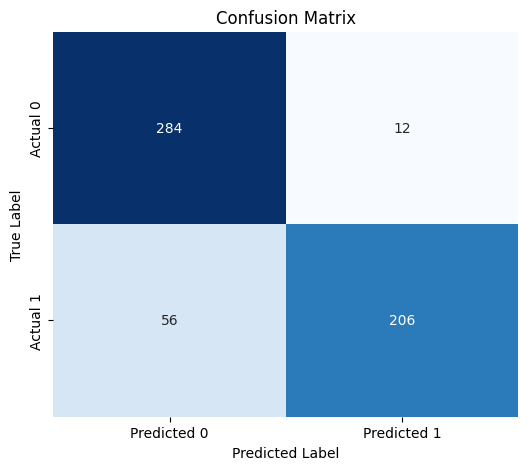

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


metrics_results = evaluate_model(y_test, y_pred, verbose=False)
cm = metrics_results['cm']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
FAN_POWER = 75        # Watts
PURIFIER_POWER = 40   # Watts
DT = 1                # seconds per sample
THRESHOLD = 0.65

# -----------------------------
# SYSTEM SIMULATION (Fan)
# -----------------------------
def simulate_system(y_true, y_pred):
    co2, pm = 400, 10
    co2_list, pm_list = [], []

    for occ, fan in zip(y_true, y_pred):

        # CO2 dynamics
        co2 += 2.0 if occ else 0.2
        if fan:
            co2 -= 1.5

        # PM dynamics
        if occ:
            pm += 0.5
        if fan:
            pm -= 0.4

        co2 = max(350, co2)
        pm = max(5, pm)

        co2_list.append(co2)
        pm_list.append(pm)

    return np.array(co2_list), np.array(pm_list)

# -----------------------------
# PURIFIER SIMULATION
# -----------------------------
def simulate_purifier(y_true):
    co2, pm = 400, 10
    co2_list, pm_list = [], []

    for occ in y_true:
        if occ:
            co2 += 2.0
            pm += 0.5

        pm -= 1.2  # purifier effect

        co2 = max(350, co2)
        pm = max(2, pm)

        co2_list.append(co2)
        pm_list.append(pm)

    return np.array(co2_list), np.array(pm_list)

# -----------------------------
# ENERGY
# -----------------------------
def compute_energy(y_pred, power):
    return (np.sum(y_pred) * DT / 3600) * power

# -----------------------------
# AQI PROXY
# -----------------------------
def compute_aqi_series(co2, pm):
    co2_score = (co2 - 400) / 600
    pm_score = pm / 50
    return 0.6 * co2_score + 0.4 * pm_score

# -----------------------------
# MAIN PIPELINE
# -----------------------------
def run_simulation(model, X_test, y_test):

    # Predictions
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= THRESHOLD).astype(int)

    # Systems
    co2_i, pm_i = simulate_system(y_test, y_test)
    co2_m, pm_m = simulate_system(y_test, y_pred)

    y_on = np.ones_like(y_test)
    co2_on, pm_on = simulate_system(y_test, y_on)

    co2_p, pm_p = simulate_purifier(y_test)

    # Energy
    e_i = compute_energy(y_test, FAN_POWER)
    e_m = compute_energy(y_pred, FAN_POWER)
    e_on = compute_energy(y_on, FAN_POWER)
    e_p = (len(y_test) * DT / 3600) * PURIFIER_POWER

    # AQI
    aqi_i = np.mean(compute_aqi_series(co2_i, pm_i))
    aqi_m = np.mean(compute_aqi_series(co2_m, pm_m))
    aqi_on = np.mean(compute_aqi_series(co2_on, pm_on))
    aqi_p = np.mean(compute_aqi_series(co2_p, pm_p))

    # Extra metrics
    wasted_time = np.sum((y_pred == 1) & (y_test == 0)) * DT
    missed_time = np.sum((y_pred == 0) & (y_test == 1)) * DT

    wasted_energy = (wasted_time / 3600) * FAN_POWER

    # Table
    df = pd.DataFrame([
        ["Ideal", e_i, np.mean(co2_i), np.mean(pm_i), aqi_i],
        ["AI System (0.65)", e_m, np.mean(co2_m), np.mean(pm_m), aqi_m],
        ["Always ON Fan", e_on, np.mean(co2_on), np.mean(pm_on), aqi_on],
        ["Purifier", e_p, np.mean(co2_p), np.mean(pm_p), aqi_p],
    ], columns=["System", "Energy (Wh)", "CO2", "PM", "AQI"])

    print(df)

    print("\n--- Additional Metrics ---")
    print(f"Wasted Energy (FP): {wasted_energy:.2f} Wh")
    print(f"Missed Occupancy Time (FN): {missed_time:.2f} sec")

    return co2_i, co2_m, co2_on, co2_p, pm_i, pm_m, pm_on, pm_p, df

# -----------------------------
# GRAPH SECTION
# -----------------------------
def plot_results(co2_i, co2_m, co2_on, co2_p,
                 pm_i, pm_m, pm_on, pm_p):

    # CO2 plot
    plt.figure()
    plt.plot(co2_i, label="Ideal")
    plt.plot(co2_m, label="AI System")
    plt.plot(co2_on, label="Always ON Fan")
    plt.plot(co2_p, label="Purifier")
    plt.title("CO2 Levels Over Time")
    plt.xlabel("Time")
    plt.ylabel("CO2 (ppm)")
    plt.legend()
    plt.grid()
    plt.show()

    # PM plot
    plt.figure()
    plt.plot(pm_i, label="Ideal")
    plt.plot(pm_m, label="AI System")
    plt.plot(pm_on, label="Always ON Fan")
    plt.plot(pm_p, label="Purifier")
    plt.title("PM Levels Over Time")
    plt.xlabel("Time")
    plt.ylabel("PM (ug/m3)")
    plt.legend()
    plt.grid()
    plt.show()
def plot_energy_bar(df):
    plt.figure()
    plt.bar(df["System"], df["Energy (Wh)"])
    plt.title("Energy Consumption Comparison")
    plt.xlabel("System")
    plt.ylabel("Energy (Wh)")
    plt.xticks(rotation=20)
    plt.grid(axis='y')
    plt.show()

             System  Energy (Wh)         CO2         PM       AQI
0             Ideal     5.458333  495.127419  23.075806  0.279734
1  AI System (0.65)     5.125000  510.197312  27.094444  0.326953
2     Always ON Fan    11.625000  354.115591   5.187276 -0.004386
3          Purifier     6.200000  661.516129   2.049104  0.277909

--- Additional Metrics ---
Wasted Energy (FP): 0.48 Wh
Missed Occupancy Time (FN): 39.00 sec


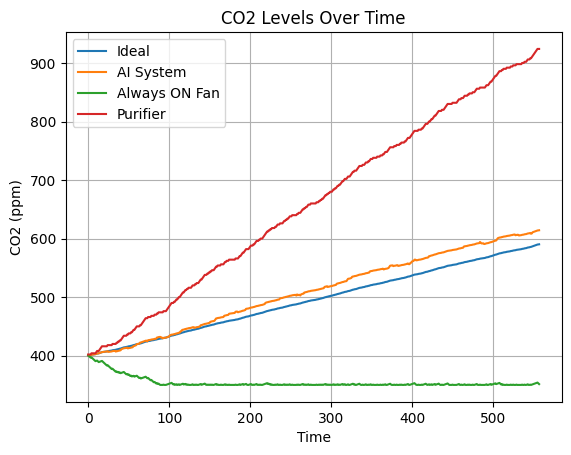

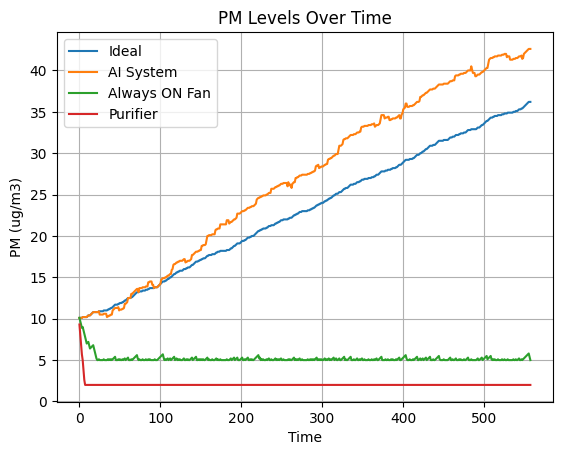

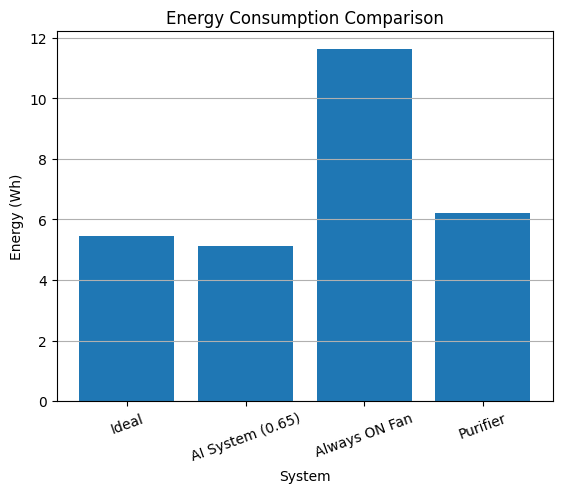

In [ ]:
# Run the simulation and get the results
co2_i, co2_m, co2_on, co2_p, pm_i, pm_m, pm_on, pm_p, df_results = run_simulation(model, X_test, y_test)

# Plot the results
plot_results(co2_i, co2_m, co2_on, co2_p, pm_i, pm_m, pm_on, pm_p)
plot_energy_bar(df_results)